# DPS Step Memory Profiler
Measures peak GPU memory of one full gradient computation step.
Imports directly from `run_dps.py` and `generation.py`.

In [1]:
!pip install controlnet_aux diffusers transformers accelerate xformers scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 124.6 MB/s eta 0:00:00


In [2]:
import os
import sys
from huggingface_hub import login
from google.colab import userdata
import wandb
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from PIL import Image

hf_token = userdata.get('HF')
if hf_token:
    login(token=hf_token)
else:
    login()

if 'google.colab' in str(get_ipython()):
    import getpass

    !pip install -q diffusers transformers accelerate xformers
    !pip install -q scikit-learn matplotlib Pillow

    github_token = userdata.get('GITHUB')
    if github_token:
        token = github_token
    else:
        token = getpass.getpass("Enter your GitHub personal access token: ")

    repo_url  = f"https://{token}@github.com/orineo1/conditional-matching-paper.git"
    repo_name = "conditional-matching-paper"
    branch    = "SD-add-vis-and-table"

    if not os.path.exists(repo_name):
        !git clone {repo_url}
    else:
        print(f"✅ Repo '{repo_name}' already cloned — pulling latest...")
        !cd {repo_name} && git pull

    !cd {repo_name} && git checkout {branch}

    repo_path = f"/content/{repo_name}"
    if repo_path not in sys.path:
        sys.path.insert(0, repo_path)

    print(f"\n✅ Repo ready. Branch: {branch}")
    print(f"📁 Python path: {repo_path}")

repo_path = f"/content/{repo_name}/SD_cond_SD_controlnet"
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

wandb_token = userdata.get('WANDB')
if wandb_token:
    wandb.login(key=wandb_token)
else:
    wandb.login()

Cloning into 'conditional-matching-paper'...
remote: Enumerating objects: 5326, done.
remote: Counting objects: 100% (215/215), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 5326 (delta 146), reused 136 (delta 80), pack-reused 5111 (from 3)
Receiving objects: 100% (5326/5326), 1.05 GiB | 17.34 MiB/s, done.
Resolving deltas: 100% (1307/1307), done.
Branch 'SD-add-vis-and-table' set up to track remote branch 'SD-add-vis-and-table' from 'origin'.
Switched to a new branch 'SD-add-vis-and-table'

✅ Repo ready. Branch: SD-add-vis-and-table
📁 Python path: /content/conditional-matching-paper


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ori-meidler (conditional-matching) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
! pip install controlnet_aux -q

## 1. Config

In [4]:
NUM_VARIATIONS = 100      # N variations
N_TARGETS      = 100      # M targets (detached, costs nothing in grad)
BASE_ZETA      = 5.0
TURBO_STEPS    = 2        # sprinter inference steps (current)
BASE_STEPS     = 30       # SDXL Base steps (hypothetical)

ARCHITECT_MODEL_ID  = 'stabilityai/sdxl-turbo'
SPRINTER_MODEL_ID   = 'stabilityai/sdxl-turbo'
CONTROLNET_MODEL_ID = 'xinsir/controlnet-scribble-sdxl-1.0'

VARIATION_PROMPT    = 'a superrealistic professional photograph of'
TARGET_MAN_PROMPT   = 'a superrealistic portrait photograph of a man, studio lighting'
TARGET_WOMAN_PROMPT = 'a superrealistic portrait photograph of a woman, studio lighting'

## 2. Memory helpers

In [5]:
import gc

def reset_mem():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

def current_mb():
    return torch.cuda.memory_allocated() / 1e6

def peak_mb():
    return torch.cuda.max_memory_allocated() / 1e6

def report(label, baseline_mb):
    cur  = current_mb()
    peak = peak_mb()
    print(f'  {label}')
    print(f'    current : {cur:.0f} MB')
    print(f'    peak    : {peak:.0f} MB')
    print(f'    net peak: {peak - baseline_mb:.0f} MB  (above pre-step baseline)')
    return peak

## 3. Load models

In [6]:
from models import load_models, setup_gradient_checkpointing
from clip_utils import load_clip_model, encode_images_clip

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')
print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

reset_mem()
architect, sprinter = load_models(
    device,
    architect_model_id=ARCHITECT_MODEL_ID,
    sprinter_model_id=SPRINTER_MODEL_ID,
    controlnet_model_id=CONTROLNET_MODEL_ID,
)
clip_model, clip_processor = load_clip_model(device)
sprinter.vae.to(dtype=torch.float32)
setup_gradient_checkpointing(architect, sprinter)

MODELS_MB = current_mb()
print(f'\nModels loaded. VRAM used: {MODELS_MB:.0f} MB')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device : cuda
GPU    : NVIDIA A100-SXM4-80GB
VRAM   : 85.1 GB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/2.50G [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Models loaded. VRAM used: 18713 MB


## 4. Build targets + scribble

In [7]:
import torchvision.transforms as T
from image_utils import build_base_image, sobel_proxy
from generation  import generate_and_store_cs
from run_dps     import extract_scribble_hed, pil_images_to_tensor

# Oval scribble as controlnet conditioning
_, base_tensor = build_base_image(device)
with torch.no_grad():
    sobel_cond_pil = T.ToPILImage()(sobel_proxy(base_tensor, device).squeeze(0).cpu())

# Generate N_TARGETS target images and encode to CLIP (all detached — costs nothing in grad graph)
n_half = N_TARGETS // 2
print(f'Generating {N_TARGETS} target images ({n_half} man + {n_half} woman)...')
with torch.no_grad():
    man_imgs,   _ = generate_and_store_cs(sprinter, TARGET_MAN_PROMPT,   sobel_cond_pil, n_half, batch_size=2, cn_scale=0.5)
    woman_imgs, _ = generate_and_store_cs(sprinter, TARGET_WOMAN_PROMPT, sobel_cond_pil, n_half, batch_size=2, cn_scale=0.5)

    man_embs   = encode_images_clip(pil_images_to_tensor(man_imgs,   device), clip_model, clip_processor)
    woman_embs = encode_images_clip(pil_images_to_tensor(woman_imgs, device), clip_model, clip_processor)

all_clip_embeddings = torch.cat([man_embs, woman_embs], dim=0)  # [N_TARGETS, 768] — will be detached
print(f'Target CLIP embeddings: {all_clip_embeddings.shape}')
print(f'Note: targets are fully detached in grad computation — M={N_TARGETS} costs nothing in graph')

scribble_pil = extract_scribble_hed(man_imgs[0])
print('Scribble ready.')

Generating 100 target images (50 man + 50 woman)...


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/controlnet/pipeline_controlnet_sd_xl.py:928: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  Progress: 50/50
  Progress: 50/50
Target CLIP embeddings: torch.Size([100, 768])
Note: targets are fully detached in grad computation — M=100 costs nothing in graph


/usr/local/lib/python3.12/dist-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/controlnet_aux/segment_anything/modeling/tiny_vit_sam.py:654: UserWarning: Overwriting tiny_vit_5m_224 in registry with controlnet_aux.segmen

ControlNetHED.pth:   0%|          | 0.00/29.4M [00:00<?, ?B/s]

Scribble ready.


## 5. Prepare scheduler + latents for step 0

In [8]:
import copy
from generation import predict_noise_cfg, compute_pred_x0_direct

height, width = 512, 512
n_steps    = 30
start_step = 15

with torch.no_grad():
    prompt_embeds, neg_embeds, pooled_embeds, neg_pooled = architect.encode_prompt(
        prompt='', negative_prompt='', device=device,
        do_classifier_free_guidance=True, num_images_per_prompt=1,
    )

architect.scheduler.set_timesteps(n_steps, device=device)
timesteps = architect.scheduler.timesteps

add_time_ids = torch.tensor(
    [[height, width, 0, 0, height, width]], dtype=prompt_embeds.dtype, device=device
)
added_cond_kwargs = {
    'text_embeds': torch.cat([neg_pooled, pooled_embeds], dim=0),
    'time_ids':    add_time_ids.repeat(2, 1),
}
cfg_encoder_states = torch.cat([neg_embeds, prompt_embeds], dim=0)

with torch.no_grad():
    scribble_t   = TF.to_tensor(scribble_pil).unsqueeze(0).to(device).float()
    scribble_t   = scribble_t * 2.0 - 1.0
    scribble_lat = architect.vae.encode(scribble_t).latent_dist.mean
    scribble_lat = scribble_lat * architect.vae.config.scaling_factor

t_start = timesteps[start_step]
alpha   = architect.scheduler.alphas_cumprod[t_start.long()].to(device).float()
noise   = torch.randn_like(scribble_lat)
latents = ((alpha**0.5) * scribble_lat + ((1-alpha)**0.5) * noise).to(torch.float16)
t       = timesteps[start_step]

print(f'Latents shape   : {latents.shape}')
print(f'Timestep        : t={t.item():.0f}')
print(f'VRAM before step: {current_mb():.0f} MB')

Latents shape   : torch.Size([1, 4, 64, 64])
Timestep        : t=499
VRAM before step: 18733 MB


## 6. Measure gradient computation memory
This cell runs the full DPS gradient step and reports memory at each sub-stage.

In [9]:
from generation import run_dps_step_clip
from metrics    import compute_mmd
import time

# ── Baseline: models loaded, no grad graph ────────────────────
reset_mem()
BASELINE_MB = current_mb()
print(f'Baseline VRAM (models only): {BASELINE_MB:.0f} MB\n')

# ── Stage 1: architect UNet forward ──────────────────────────
latents_step = latents.detach().requires_grad_(True)
noise_pred = predict_noise_cfg(
    architect.unet, architect.scheduler,
    latents_step, t, cfg_encoder_states, added_cond_kwargs, 0.0,
)
AFTER_UNET_MB = report('Stage 1 — architect UNet forward (noise_pred)', BASELINE_MB)
print()

# ── Stage 2: pred_x0 ─────────────────────────────────────────
pred_x0 = compute_pred_x0_direct(architect.scheduler, noise_pred, t, latents_step)
AFTER_PRED_X0_MB = report('Stage 2 — compute_pred_x0_direct', BASELINE_MB)
print()

# ── Stage 3: VAE decode pred_x0 -> pixels ────────────────────
pred_x0_scaled = pred_x0 / architect.vae.config.scaling_factor
pixel_x0 = torch.utils.checkpoint.checkpoint(
    lambda lat: architect.vae.decode(lat.to(architect.vae.dtype)).sample,
    pred_x0_scaled, use_reentrant=False,
)
pixel_x0_norm = torch.clamp((pixel_x0.float() + 1.0) / 2.0, 0.0, 1.0)

# ── record fixed graph peak — everything before variations ────
FIXED_PEAK_MB = peak_mb()
report('Stage 3 — VAE decode -> pixel_x0_norm  [END OF FIXED GRAPH]', BASELINE_MB)
print()

# ── Stage 4: N variations + MMD + autograd.grad ───────────────
print(f'Stage 4 — run_dps_step_clip  (N={NUM_VARIATIONS} variations, K={TURBO_STEPS} steps each)...')
torch.cuda.synchronize()
t0 = time.perf_counter()

grad, mmd_loss, zeta_i, loss_norm, vl_clip_flat = run_dps_step_clip(
    latents              = latents,
    latents_step         = latents_step,
    noise_pred           = noise_pred,
    pixel_x0_norm        = pixel_x0_norm,
    sprinter             = sprinter,
    all_clip_embeddings  = all_clip_embeddings,
    num_variations       = NUM_VARIATIONS,
    variation_batch_size = 1,
    base_zeta_prime      = BASE_ZETA,
    clip_model           = clip_model,
    clip_processor       = clip_processor,
    vae                  = sprinter.vae,
    vae_scaling_factor   = sprinter.vae.config.scaling_factor,
    variation_prompt     = VARIATION_PROMPT,
    loss_fn              = compute_mmd,
)

torch.cuda.synchronize()
GRAD_TIME_TURBO = time.perf_counter() - t0
GRAD_TIME_BASE_PROJECTED = GRAD_TIME_TURBO * (BASE_STEPS / TURBO_STEPS)

TOTAL_PEAK_MB = peak_mb()
report('Stage 4 — after run_dps_step_clip (incl. autograd.grad)', BASELINE_MB)

print(f'\n  grad norm : {grad.norm().item():.6f}')
print(f'  MMD loss  : {mmd_loss.item():.6f}')
print()
print(f'  Gradient step time (Turbo, K={TURBO_STEPS}, N={NUM_VARIATIONS}): {GRAD_TIME_TURBO:.2f} s')
print(f'  Gradient step time (Base,  K={BASE_STEPS}, N={NUM_VARIATIONS}):  {GRAD_TIME_BASE_PROJECTED:.2f} s  (projected ×{BASE_STEPS//TURBO_STEPS})')

Baseline VRAM (models only): 18733 MB

  Stage 1 — architect UNet forward (noise_pred)
    current : 18989 MB
    peak    : 19019 MB
    net peak: 286 MB  (above pre-step baseline)

  Stage 2 — compute_pred_x0_direct
    current : 18989 MB
    peak    : 19019 MB
    net peak: 286 MB  (above pre-step baseline)

  Stage 3 — VAE decode -> pixel_x0_norm  [END OF FIXED GRAPH]
    current : 18999 MB
    peak    : 19998 MB
    net peak: 1265 MB  (above pre-step baseline)

Stage 4 — run_dps_step_clip  (N=100 variations, K=2 steps each)...


/content/conditional-matching-paper/SD_cond_SD_controlnet/generation.py:165: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


      var_clip_embs: shape=torch.Size([100, 768]) nan=0 range=[-0.4927, 0.5270] grad_fn=<CatBackward0 object at 0x79d0338394b0>
  Stage 4 — after run_dps_step_clip (incl. autograd.grad)
    current : 36605 MB
    peak    : 43677 MB
    net peak: 24944 MB  (above pre-step baseline)

  grad norm : 0.687988
  MMD loss  : 0.528163

  Gradient step time (Turbo, K=2, N=100): 247.86 s
  Gradient step time (Base,  K=30, N=100):  3717.85 s  (projected ×15)


## 7. Projection on SDXL Base

In [11]:
total_vram_mb = torch.cuda.get_device_properties(0).total_memory / 1e6

# ── Decompose measured peak into fixed vs variation parts ─────
fixed_graph_mb     = FIXED_PEAK_MB  - BASELINE_MB   # architect UNet + pred_x0 + VAE decode
variation_turbo_mb = TOTAL_PEAK_MB  - FIXED_PEAK_MB  # N variations with Turbo (K=2 steps)

# ── Project Base (K=30 steps) ─────────────────────────────────
# With checkpointing ON:
#   - Fixed graph is identical (same architect UNet, same VAE)
#   - Variation memory scales with K because each variation has
#     K×(graph nodes + recompute metadata) instead of 2×
#   - The 15× comes from K_base/K_turbo = 30/2
step_ratio             = BASE_STEPS / TURBO_STEPS          # = 15
variation_base_mb      = variation_turbo_mb * step_ratio
projected_base_peak_mb = BASELINE_MB + fixed_graph_mb + variation_base_mb

print('=' * 55)
print('  MEMORY BREAKDOWN — Turbo (measured)')
print('=' * 55)
print(f'  Models baseline         : {BASELINE_MB:.0f} MB')
print(f'  Fixed graph (stages 1-3): {fixed_graph_mb:.0f} MB')
print(f'  Variation graph (N={NUM_VARIATIONS}, K={TURBO_STEPS}): {variation_turbo_mb:.0f} MB')
print(f'  Total peak (measured)   : {TOTAL_PEAK_MB:.0f} MB')
print(f'  GPU total VRAM          : {total_vram_mb:.0f} MB')
print(f'  Headroom                : {total_vram_mb - TOTAL_PEAK_MB:.0f} MB')

print()
print('=' * 55)
print('  PROJECTION — SDXL Base (K=30, checkpointing ON)')
print('=' * 55)
print(f'  Models baseline         : {BASELINE_MB:.0f} MB  (identical — same UNet arch)')
print(f'  Fixed graph (stages 1-3): {fixed_graph_mb:.0f} MB  (identical)')
print(f'  Variation graph (N={NUM_VARIATIONS}, K={BASE_STEPS}): {variation_base_mb:.0f} MB  ({step_ratio}× Turbo)')
print(f'  Projected peak          : {projected_base_peak_mb:.0f} MB')
print(f'  Fits in GPU?            : {"YES" if projected_base_peak_mb < total_vram_mb else "NO — would OOM"}')
print(f'  Overhead vs Turbo       : +{projected_base_peak_mb - TOTAL_PEAK_MB:.0f} MB')

print()
print('=' * 55)
print('  NOTE ON TARGETS (M)')
print('=' * 55)
print(f'  M={N_TARGETS} targets are fully detached — zero grad graph cost.')
print(f'  Increasing M from 6 to {N_TARGETS} adds only MMD kernel memory:')
kxy_mb = (NUM_VARIATIONS * N_TARGETS * 4) / 1e6
print(f'  K_xy [{NUM_VARIATIONS}×{N_TARGETS}] = {kxy_mb:.2f} MB  (negligible)')

  MEMORY BREAKDOWN — Turbo (measured)
  Models baseline         : 18733 MB
  Fixed graph (stages 1-3): 1265 MB
  Variation graph (N=100, K=2): 23679 MB
  Total peak (measured)   : 43677 MB
  GPU total VRAM          : 85095 MB
  Headroom                : 41417 MB

  PROJECTION — SDXL Base (K=30, checkpointing ON)
  Models baseline         : 18733 MB  (identical — same UNet arch)
  Fixed graph (stages 1-3): 1265 MB  (identical)
  Variation graph (N=100, K=30): 355187 MB  (15.0× Turbo)
  Projected peak          : 375185 MB
  Fits in GPU?            : NO — would OOM
  Overhead vs Turbo       : +331508 MB

  NOTE ON TARGETS (M)
  M=100 targets are fully detached — zero grad graph cost.
  Increasing M from 6 to 100 adds only MMD kernel memory:
  K_xy [100×100] = 0.04 MB  (negligible)


## Speed

Loading SDXL Base + ControlNet...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

✅ Loaded.
Generating Turbo sample (K=2, guidance=0.0)...
Generating Base sample (K=30, guidance=7.5)...


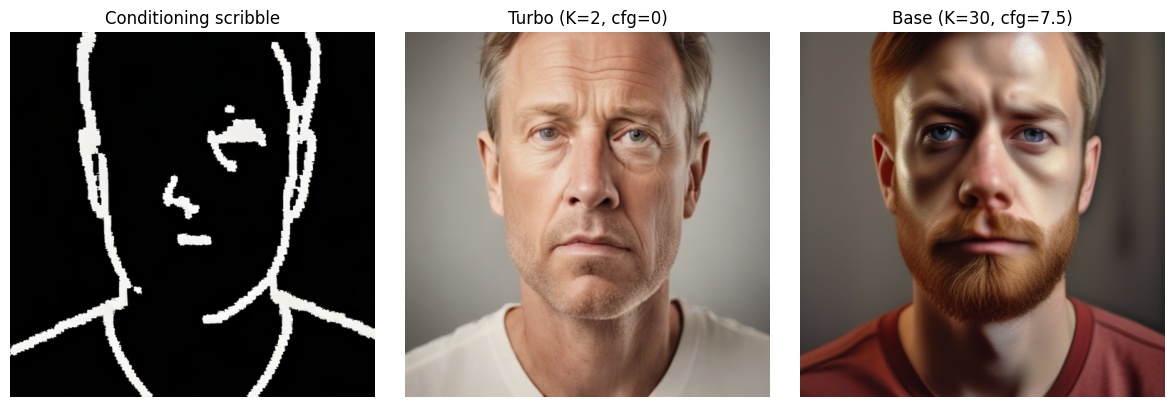


Timing Turbo (K=2)...
Timing Base (K=30, guidance=7.5)...

Turbo (K=2, cfg=0.0) : 0.386 s ± 0.006 s per variation
Base  (K=30, cfg=7.5)  : 5.040 s ± 0.040 s per variation
  note: Base runs 2× UNet per step (CFG) vs Turbo 1×

Speedup per variation          : 13.0×
Turbo full step  (N=100)     : 0.6 min
Base  full step  (N=100)     : 8.4 min
Turbo full loop  (15 steps)  : 0.16 hr
Base  full loop  (15 steps)  : 2.10 hr

✅ Done. Sprinter VAE restored to float32.


In [14]:
import time, gc
from IPython.display import display
from diffusers import StableDiffusionXLControlNetPipeline, ControlNetModel
from torchvision.transforms.functional import to_pil_image

BASE_GUIDANCE_SCALE = 7.5
BASE_STEPS          = 30
TURBO_STEPS         = 2
N_TIMING            = 15

# ── Load Base + ControlNet ────────────────────────────────────
print('Loading SDXL Base + ControlNet...')
controlnet_base = ControlNetModel.from_pretrained(
    CONTROLNET_MODEL_ID, torch_dtype=torch.float16, use_safetensors=True,
).to(device)

sprinter_base = StableDiffusionXLControlNetPipeline.from_pretrained(
    'stabilityai/stable-diffusion-xl-base-1.0',
    controlnet=controlnet_base,
    torch_dtype=torch.float16, variant='fp16', use_safetensors=True,
).to(device)
sprinter_base.set_progress_bar_config(disable=True)

sprinter.vae.to(dtype=torch.float16)
sprinter_base.vae.to(dtype=torch.float16)
print('✅ Loaded.')

# ── Conditioning image ────────────────────────────────────────
cond_pil = to_pil_image(pixel_x0_norm.squeeze(0).cpu().float())

# ── Generate sample images ────────────────────────────────────
print(f'Generating Turbo sample (K={TURBO_STEPS}, guidance=0.0)...')
with torch.no_grad():
    turbo_img = sprinter(
        prompt=[VARIATION_PROMPT], image=[cond_pil],
        num_inference_steps=TURBO_STEPS, guidance_scale=0.0,
        controlnet_conditioning_scale=0.8, output_type='pil',
    ).images[0]

print(f'Generating Base sample (K={BASE_STEPS}, guidance={BASE_GUIDANCE_SCALE})...')
with torch.no_grad():
    base_img = sprinter_base(
        prompt=[VARIATION_PROMPT], image=[cond_pil],
        num_inference_steps=BASE_STEPS, guidance_scale=BASE_GUIDANCE_SCALE,
        controlnet_conditioning_scale=0.8, output_type='pil',
    ).images[0]

# ── Show side by side ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(
    axes,
    [cond_pil, turbo_img, base_img],
    ['Conditioning scribble', f'Turbo (K={TURBO_STEPS}, cfg=0)', f'Base (K={BASE_STEPS}, cfg={BASE_GUIDANCE_SCALE})'],
):
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title)
plt.tight_layout()
display(fig)
plt.close()

# ── Time Turbo ────────────────────────────────────────────────
print(f'\nTiming Turbo (K={TURBO_STEPS})...')
times_turbo = []
for _ in range(N_TIMING):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = sprinter(
            prompt=[VARIATION_PROMPT], image=[cond_pil],
            num_inference_steps=TURBO_STEPS, guidance_scale=0.0,
            controlnet_conditioning_scale=0.8, output_type='latent',
        ).images
    torch.cuda.synchronize()
    times_turbo.append(time.perf_counter() - t0)

mean_turbo = sum(times_turbo) / N_TIMING
std_turbo  = (sum((t - mean_turbo)**2 for t in times_turbo) / N_TIMING) ** 0.5

# ── Time Base ─────────────────────────────────────────────────
print(f'Timing Base (K={BASE_STEPS}, guidance={BASE_GUIDANCE_SCALE})...')
times_base = []
for _ in range(N_TIMING):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = sprinter_base(
            prompt=[VARIATION_PROMPT], image=[cond_pil],
            num_inference_steps=BASE_STEPS, guidance_scale=BASE_GUIDANCE_SCALE,
            controlnet_conditioning_scale=0.8, output_type='latent',
        ).images
    torch.cuda.synchronize()
    times_base.append(time.perf_counter() - t0)

mean_base = sum(times_base) / N_TIMING
std_base  = (sum((t - mean_base)**2 for t in times_base) / N_TIMING) ** 0.5

# ── Summary ───────────────────────────────────────────────────
speedup       = mean_base / mean_turbo
dps_steps_run = n_steps - start_step

print(f'\nTurbo (K={TURBO_STEPS}, cfg=0.0) : {mean_turbo:.3f} s ± {std_turbo:.3f} s per variation')
print(f'Base  (K={BASE_STEPS}, cfg={BASE_GUIDANCE_SCALE})  : {mean_base:.3f} s ± {std_base:.3f} s per variation')
print(f'  note: Base runs 2× UNet per step (CFG) vs Turbo 1×')
print()
print(f'Speedup per variation          : {speedup:.1f}×')
print(f'Turbo full step  (N={NUM_VARIATIONS})     : {mean_turbo * NUM_VARIATIONS / 60:.1f} min')
print(f'Base  full step  (N={NUM_VARIATIONS})     : {mean_base  * NUM_VARIATIONS / 60:.1f} min')
print(f'Turbo full loop  ({dps_steps_run} steps)  : {mean_turbo * NUM_VARIATIONS * dps_steps_run / 3600:.2f} hr')
print(f'Base  full loop  ({dps_steps_run} steps)  : {mean_base  * NUM_VARIATIONS * dps_steps_run / 3600:.2f} hr')

# ── Restore and cleanup ───────────────────────────────────────
sprinter.vae.to(dtype=torch.float32)
del sprinter_base, controlnet_base
gc.collect()
torch.cuda.empty_cache()
print('\n✅ Done. Sprinter VAE restored to float32.')